# Atividade 04 - Pipeline de Visão Computacional

## 1. Introdução

Este notebook foi preparado para executar um pipeline simples e didático de visão computacional no Google Colab. A proposta é trabalhar com uma imagem autoral enviada pelo estudante, aplicando etapas clássicas de processamento sem usar inteligência artificial, redes neurais ou modelos treinados.

O fluxo implementado segue esta sequência:

- aquisição da imagem;
- segmentação por limiarização de Otsu;
- operações morfológicas para reduzir ruído e corrigir pequenas falhas;
- identificação de objetos por componentes conectados;
- extração de características;
- análise dos resultados.

O notebook também foi preparado para não quebrar caso a imagem ainda não esteja no caminho esperado. Nesse caso, as células exibem orientações claras para que o estudante possa organizar o arquivo e continuar a execução sem erros.

In [1]:
# Bibliotecas principais usadas ao longo da atividade.
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from skimage import io, color, filters, morphology, measure

# Configuracoes basicas do notebook.
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.titlesize'] = 12

# Caminho padrao solicitado na atividade.
DEFAULT_IMAGE_PATH = Path('imagens/imagem_atividade04.jpg')

# Parametros simples que o estudante pode ajustar depois.
GAUSSIAN_SIGMA = 1.0
INVERTER_MASCARA = True
MIN_AREA = 1000
AREA_MAXIMA = 6000

# Dicionario para compartilhar os dados entre as celulas sem complicar o codigo.
pipeline = {}

print('Notebook inicializado para uso no Google Colab.')
print(f'Caminho padrao da imagem: {DEFAULT_IMAGE_PATH}')
print(f'Parametros atuais -> sigma: {GAUSSIAN_SIGMA}, inverter mascara: {INVERTER_MASCARA}, area minima: {MIN_AREA}, area maxima: {AREA_MAXIMA}')

Notebook inicializado para uso no Google Colab.
Caminho padrao da imagem: imagens\imagem_atividade04.jpg
Parametros atuais -> sigma: 1.0, inverter mascara: True, area minima: 1000, area maxima: 6000


## 2. Aquisição da imagem

Nesta etapa, o notebook tenta carregar automaticamente a imagem a partir do caminho `imagens/imagem_atividade04.jpg`. Esse caminho foi mantido como padrão para facilitar a organização do projeto no Colab.

Se a imagem ainda não existir, nenhuma célula vai falhar. Em vez disso, será exibida uma mensagem explicando onde o arquivo deve ser colocado. Isso permite que o notebook seja preparado agora e reutilizado depois com a imagem autoral do estudante.

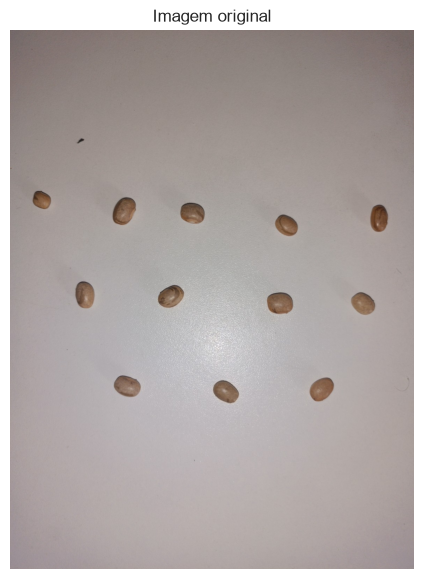

Imagem carregada com sucesso: imagens\imagem_atividade04.jpg


In [2]:
# Garante que a pasta exista no ambiente do Colab.
DEFAULT_IMAGE_PATH.parent.mkdir(parents=True, exist_ok=True)

if DEFAULT_IMAGE_PATH.exists():
    image = io.imread(DEFAULT_IMAGE_PATH)

    # Ajustes simples para lidar com imagens em tons de cinza ou com canal alfa.
    if image.ndim == 2:
        image_rgb = color.gray2rgb(image)
    elif image.ndim == 3 and image.shape[2] == 4:
        image_rgb = color.rgba2rgb(image)
    else:
        image_rgb = image

    pipeline['image_rgb'] = image_rgb
    pipeline['image_path'] = DEFAULT_IMAGE_PATH

    plt.figure(figsize=(7, 7))
    plt.imshow(image_rgb, cmap='gray' if image_rgb.ndim == 2 else None)
    plt.title('Imagem original')
    plt.axis('off')
    plt.show()

    print(f'Imagem carregada com sucesso: {DEFAULT_IMAGE_PATH}')
else:
    pipeline['image_rgb'] = None
    pipeline['image_path'] = DEFAULT_IMAGE_PATH
    print('Imagem nao encontrada.')
    print('Coloque o arquivo em: imagens/imagem_atividade04.jpg')
    print('Depois disso, execute novamente esta celula e as proximas etapas do notebook.')

## 3. Segmentação

A segmentação separa os objetos de interesse do fundo. Neste notebook, foi escolhida a limiarização de Otsu porque ela é uma técnica clássica, simples e adequada para imagens com contraste razoável entre objeto e fundo.

Antes da limiarização, a imagem é convertida para tons de cinza. Opcionalmente, também é aplicado um suavizamento gaussiano leve para reduzir pequenas variações e ruído. Caso o fundo seja destacado no lugar dos objetos, a máscara pode ser invertida sem alterar o restante do pipeline.

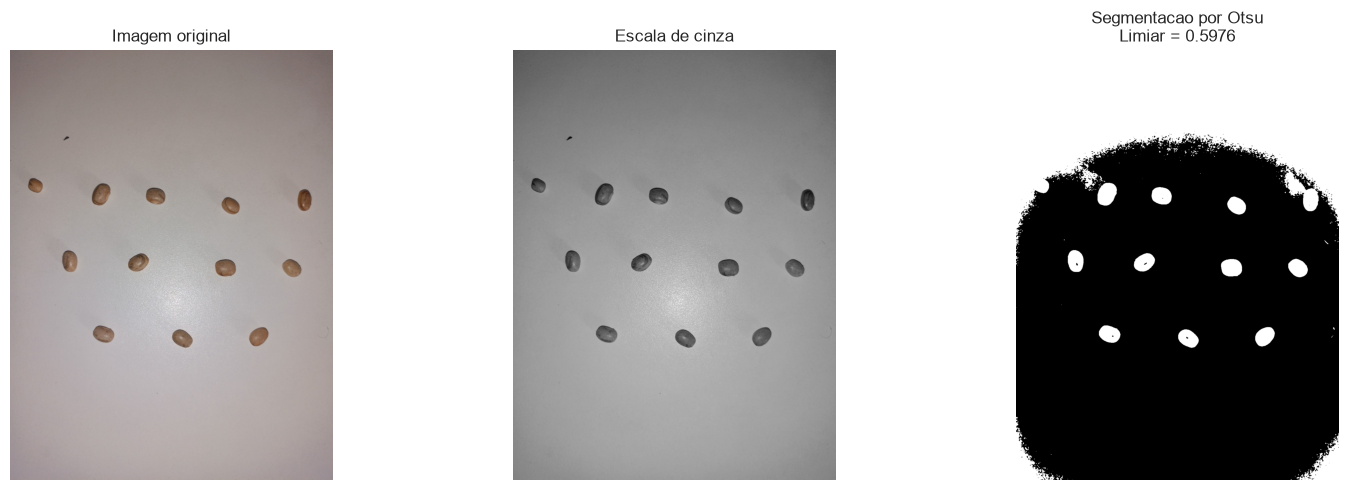

Limiar calculado por Otsu: 0.5976
Inversao manual da mascara: True


In [4]:
image_rgb = pipeline.get('image_rgb')

if image_rgb is None:
    print('Segmentacao nao executada porque a imagem ainda nao foi encontrada.')
    print('Adicione o arquivo em imagens/imagem_atividade04.jpg e rode novamente a secao de aquisicao.')
else:
    image_gray = color.rgb2gray(image_rgb)
    image_suave = filters.gaussian(image_gray, sigma=GAUSSIAN_SIGMA)
    limiar_otsu = filters.threshold_otsu(image_suave)

    if INVERTER_MASCARA:
        mascara_binaria = image_suave < limiar_otsu
    else:
        mascara_binaria = image_suave > limiar_otsu

    pipeline['image_gray'] = image_gray
    pipeline['image_suave'] = image_suave
    pipeline['limiar_otsu'] = limiar_otsu
    pipeline['mascara_binaria'] = mascara_binaria

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(image_rgb)
    axes[0].set_title('Imagem original')
    axes[0].axis('off')

    axes[1].imshow(image_gray, cmap='gray')
    axes[1].set_title('Escala de cinza')
    axes[1].axis('off')

    axes[2].imshow(mascara_binaria, cmap='gray')
    axes[2].set_title(f'Segmentacao por Otsu\nLimiar = {limiar_otsu:.4f}')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

    print(f'Limiar calculado por Otsu: {limiar_otsu:.4f}')
    print(f'Inversao manual da mascara: {INVERTER_MASCARA}')

## 4. Operações morfológicas

Depois da segmentação, é comum que sobrem pequenos ruídos ou pequenas falhas dentro dos objetos. Para tratar isso, o pipeline aplica duas operações morfológicas clássicas:

- abertura, para remover pequenos pontos isolados;
- fechamento, para preencher pequenas falhas e conectar bordas próximas.

Essas etapas ajudam a melhorar a máscara antes da contagem e da extração de características. Ao analisar os resultados, é importante verificar se essas operações reduziram ruídos sem apagar detalhes relevantes dos objetos.

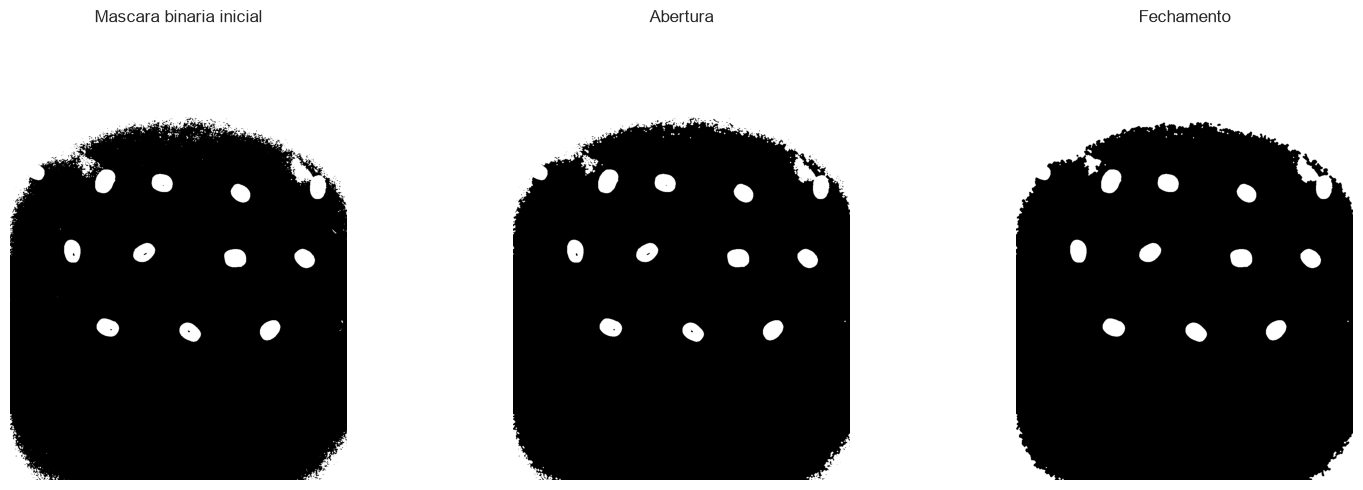

In [5]:
mascara_binaria = pipeline.get('mascara_binaria')

if mascara_binaria is None:
    print('As operacoes morfologicas nao foram executadas porque a segmentacao ainda nao foi realizada.')
else:
    elemento_abertura = morphology.disk(2)
    elemento_fechamento = morphology.disk(3)

    mascara_aberta = morphology.opening(mascara_binaria, elemento_abertura)
    mascara_fechada = morphology.closing(mascara_aberta, elemento_fechamento)

    pipeline['mascara_aberta'] = mascara_aberta
    pipeline['mascara_fechada'] = mascara_fechada

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    axes[0].imshow(mascara_binaria, cmap='gray')
    axes[0].set_title('Mascara binaria inicial')
    axes[0].axis('off')

    axes[1].imshow(mascara_aberta, cmap='gray')
    axes[1].set_title('Abertura')
    axes[1].axis('off')

    axes[2].imshow(mascara_fechada, cmap='gray')
    axes[2].set_title('Fechamento')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

## 5. Identificação de objetos

Nesta etapa, os objetos são identificados com base em componentes conectados. Cada região branca da máscara final passa a ser tratada como um objeto candidato.

Também é aplicado um filtro por área mínima para remover pequenos resíduos que ainda possam ter permanecido após as operações morfológicas. Esse filtro é útil, mas deve ser observado com cuidado para não eliminar objetos pequenos que sejam relevantes para a atividade.

C:\Users\igorl\AppData\Local\Temp\ipykernel_9568\394333380.py:6: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mascara_base = morphology.remove_small_objects(mascara_fechada.astype(bool), min_size=MIN_AREA)


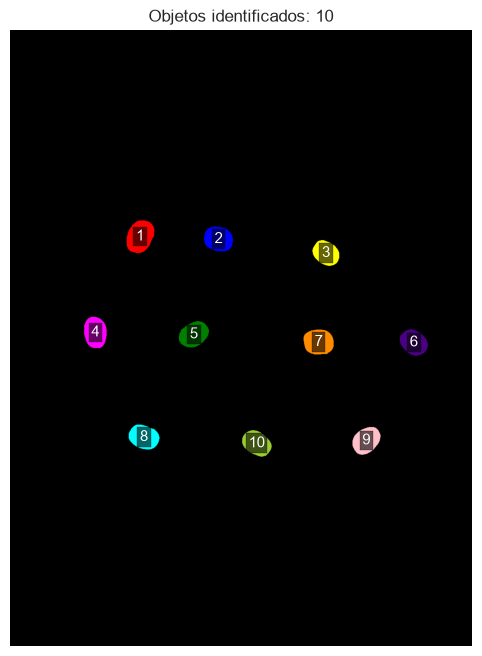

Objetos antes do filtro: 13
Objetos depois do filtro: 10
Filtro aplicado: area >= 1000 e area <= 6000


In [6]:
mascara_fechada = pipeline.get('mascara_fechada')

if mascara_fechada is None:
    print('A identificacao de objetos nao foi executada porque a mascara final ainda nao esta disponivel.')
else:
    mascara_base = morphology.remove_small_objects(mascara_fechada.astype(bool), min_size=MIN_AREA)
    rotulos_iniciais = measure.label(mascara_base)
    propriedades_iniciais = measure.regionprops(rotulos_iniciais)
    propriedades_validas = [
        regiao for regiao in propriedades_iniciais
        if MIN_AREA <= regiao.area <= AREA_MAXIMA
    ]

    mascara_filtrada = rotulos_iniciais == -1
    for regiao in propriedades_validas:
        mascara_filtrada = mascara_filtrada | (rotulos_iniciais == regiao.label)

    rotulos_filtrados = measure.label(mascara_filtrada)
    propriedades_filtradas = measure.regionprops(rotulos_filtrados)

    pipeline['mascara_filtrada'] = mascara_filtrada
    pipeline['rotulos'] = rotulos_filtrados
    pipeline['propriedades'] = propriedades_filtradas
    pipeline['regioes'] = propriedades_filtradas
    pipeline['total_objetos'] = len(propriedades_filtradas)
    pipeline['total_objetos_antes_filtro'] = len(propriedades_iniciais)
    pipeline['total_objetos_depois_filtro'] = len(propriedades_filtradas)

    imagem_rotulada = color.label2rgb(rotulos_filtrados, bg_label=0, bg_color=(0, 0, 0))

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(imagem_rotulada)
    ax.set_title(f'Objetos identificados: {len(propriedades_filtradas)}')
    ax.axis('off')

    for indice, regiao in enumerate(propriedades_filtradas, start=1):
        y_centro, x_centro = regiao.centroid
        ax.text(x_centro, y_centro, str(indice), color='white', fontsize=11,
                ha='center', va='center', bbox=dict(facecolor='black', alpha=0.6, pad=2))

    plt.show()

    print(f'Objetos antes do filtro: {len(propriedades_iniciais)}')
    print(f'Objetos depois do filtro: {len(propriedades_filtradas)}')
    print(f'Filtro aplicado: area >= {MIN_AREA} e area <= {AREA_MAXIMA}')

## 6. Extração de características

Com os objetos identificados, o próximo passo é medir propriedades que descrevem cada região. Neste notebook, são extraídas três características básicas e bastante usadas:

- área;
- perímetro;
- centroide.

Os resultados são organizados em uma tabela com `pandas`, o que facilita a leitura, a comparação entre os objetos e a elaboração da análise final.

In [7]:
propriedades = pipeline.get('propriedades')

if propriedades is None:
    print('A extracao de caracteristicas nao foi executada porque os objetos ainda nao foram rotulados.')
else:
    dados_tabela = []
    for regiao in propriedades:
        dados_tabela.append({
            'objeto': regiao.label,
            'area': regiao.area,
            'perimetro': regiao.perimeter,
            'centroide_linha': regiao.centroid[0],
            'centroide_coluna': regiao.centroid[1]
        })

    df_resultados = pd.DataFrame(dados_tabela)

    if not df_resultados.empty:
        df_resultados['area'] = df_resultados['area'].round(2)
        df_resultados['perimetro'] = df_resultados['perimetro'].round(2)
        df_resultados['centroide_linha'] = df_resultados['centroide_linha'].round(2)
        df_resultados['centroide_coluna'] = df_resultados['centroide_coluna'].round(2)

    pipeline['df_resultados'] = df_resultados

    print(f'Numero total de objetos medidos: {len(df_resultados)}')
    display(df_resultados)

Numero total de objetos medidos: 10


,objeto,area,perimetro,centroide_linha,centroide_coluna
0,1,4338.0,249.62,514.48,324.02
1,2,3608.0,223.58,520.86,519.47
2,3,3170.0,211.14,555.87,787.58
3,4,3584.0,226.17,753.64,212.35
4,5,3622.0,228.45,758.69,457.91
5,6,3391.0,217.04,778.76,1006.42
6,7,3895.0,231.92,777.64,769.18
7,8,3628.0,226.55,1014.62,333.53
8,9,3574.0,224.79,1023.16,887.92
9,10,3482.0,222.69,1030.29,614.70


## 7. Análise dos resultados

Após a execução do pipeline, foram identificados 10 objetos válidos na imagem analisada. A imagem original continha 12 feijões distribuídos sobre um fundo claro, o que indica uma pequena diferença entre a quantidade real de objetos e a quantidade detectada automaticamente.

A segmentação por limiarização de Otsu apresentou bom desempenho ao separar os feijões do fundo. As operações morfológicas de abertura e fechamento contribuíram para reduzir ruídos e melhorar a definição das regiões de interesse. Em seguida, a identificação dos objetos foi realizada por meio de componentes conectados e da extração de propriedades utilizando a função regionprops da biblioteca scikit-image.

A diferença observada entre a quantidade real e a quantidade detectada sugere que alguns objetos podem ter sido removidos durante a etapa de filtragem por área ou não terem sido segmentados de forma completamente independente. Esse comportamento é esperado em aplicações reais de Visão Computacional, pois fatores como iluminação, sombras, contraste, limiares de segmentação e critérios de filtragem podem influenciar o resultado final.

Mesmo com essa limitação, o pipeline foi capaz de detectar corretamente a maior parte dos objetos presentes na cena, demonstrando que a combinação de segmentação, operações morfológicas e análise de componentes conectados é adequada para a tarefa proposta.


In [8]:
df_resultados = pipeline.get('df_resultados')
total_objetos = pipeline.get('total_objetos', 0)
limiar_otsu = pipeline.get('limiar_otsu')

if pipeline.get('image_rgb') is None:
    display(Markdown(
        'A analise ainda nao pode ser concluida porque a imagem nao foi carregada. '
        'Adicione `imagens/imagem_atividade04.jpg` e execute novamente o notebook.'
    ))
elif df_resultados is None or df_resultados.empty:
    display(Markdown(
        'Nenhum objeto valido foi medido ate o momento. Isso pode indicar necessidade de ajustar '
        'a inversao da mascara, o nivel de suavizacao ou o valor de `MIN_AREA`.'
    ))
else:
    area_media = df_resultados['area'].mean()
    perimetro_medio = df_resultados['perimetro'].mean()

    texto_analise = f'''
### Analise critica

- **Escolha da segmentacao:** a limiarizacao de Otsu foi escolhida por ser um metodo classico, automatico e adequado para separar objeto e fundo quando existe contraste razoavel. Nesta execucao, o limiar calculado foi **{limiar_otsu:.4f}**.
- **Dificuldades possiveis:** sombras, iluminacao desigual, reflexos e objetos muito encostados podem prejudicar a segmentacao, fazendo o fundo entrar na mascara ou fazendo objetos diferentes parecerem um bloco unico.
- **Identificacao dos objetos:** o pipeline encontrou **{total_objetos}** objeto(s) apos o filtro de area minima. A verificacao visual da imagem rotulada e importante para confirmar se todos os objetos relevantes foram identificados corretamente.
- **Caracteristicas mais informativas:** a area ajuda a comparar o tamanho dos objetos, o perimetro ajuda a observar o contorno e o centroide ajuda a localizar cada objeto na imagem. Nesta amostra, a area media foi **{area_media:.2f}** e o perimetro medio foi **{perimetro_medio:.2f}**.
- **Possiveis melhorias:** o pipeline pode ser melhorado ajustando `GAUSSIAN_SIGMA`, ativando `INVERTER_MASCARA`, refinando `MIN_AREA` ou adotando tecnicas adicionais de separacao quando houver objetos muito proximos.
'''

    display(Markdown(texto_analise))


### Analise critica

- **Escolha da segmentacao:** a limiarizacao de Otsu foi escolhida por ser um metodo classico, automatico e adequado para separar objeto e fundo quando existe contraste razoavel. Nesta execucao, o limiar calculado foi **0.5976**.
- **Dificuldades possiveis:** sombras, iluminacao desigual, reflexos e objetos muito encostados podem prejudicar a segmentacao, fazendo o fundo entrar na mascara ou fazendo objetos diferentes parecerem um bloco unico.
- **Identificacao dos objetos:** o pipeline encontrou **10** objeto(s) apos o filtro de area minima. A verificacao visual da imagem rotulada e importante para confirmar se todos os objetos relevantes foram identificados corretamente.
- **Caracteristicas mais informativas:** a area ajuda a comparar o tamanho dos objetos, o perimetro ajuda a observar o contorno e o centroide ajuda a localizar cada objeto na imagem. Nesta amostra, a area media foi **3629.20** e o perimetro medio foi **226.19**.
- **Possiveis melhorias:** o pipeline pode ser melhorado ajustando `GAUSSIAN_SIGMA`, ativando `INVERTER_MASCARA`, refinando `MIN_AREA` ou adotando tecnicas adicionais de separacao quando houver objetos muito proximos.


## 8. Conclusão

Os resultados obtidos demonstram que o pipeline desenvolvido foi capaz de realizar com sucesso as etapas de aquisição da imagem, segmentação, operações morfológicas, identificação de objetos e extração de características.

Embora a quantidade de objetos detectados tenha sido ligeiramente inferior à quantidade real presente na imagem, o método apresentou desempenho satisfatório e evidenciou a importância do ajuste de parâmetros para melhorar a precisão da detecção em aplicações de Visão Computacional.
